**This notebook builds an end-to-end health Insrance cost based on the geoghraphic and lifestyle**

1. **Problem**

Build a predictive model and to see the correlation between the gene expression levels and the disease caused/progression

2. **Data**

The data we're using is from Kaggle's

 https://www.kaggle.com/datasets/ylmzasel/gene-expression-analysis-and-disease-relationship/data

*   This data comprises 1000 hypothetical patient or sample entries, each detailing gene expression profiles and relevant clinical characteristics
*   This includes demographic and health-related variables such as age, sex, BMI, number of children, smoking status, and residential region in the US
*   The target variable is charges, which represents the medical insurance cost billed to the individual.

3. **Data assesment**

  * Exploring how each variable impact the cost of the insurance

4. **Features**

  * Some information about the data:

We're dealing with structured data
There are 1338 individual (this means each have different medical cost).


In [4]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/drive/MyDrive/DataScienceMLProjects/Project 2 Gene Expression Analysis and Disease Relationship /Gene Expression Analysis and Disease Relationship.csv')
df.head()


,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
0,1,45,0,5.78,3.21,1,1,1
1,2,62,1,7.12,5.89,2,2,0
2,3,38,0,3.15,1.98,0,0,2
3,4,55,1,6.54,4.76,1,1,1
4,5,71,0,8.01,6.55,2,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   int64  
 3   Gene_X_Expression  1000 non-null   float64
 4   Gene_Y_Expression  1000 non-null   float64
 5   SmokingStatus      1000 non-null   int64  
 6   DiseaseStatus      1000 non-null   int64  
 7   TreatmentResponse  1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
df.isna().sum()

,0
PatientID,0
Age,0
Gender,0
Gene_X_Expression,0
Gene_Y_Expression,0
SmokingStatus,0
DiseaseStatus,0
TreatmentResponse,0


In [ ]:
print(df.describe())

         PatientID          Age      Gender  Gene_X_Expression  \
count  1000.000000  1000.000000  1000.00000         1000.00000   
mean    500.500000    49.631000     0.50000            3.92314   
std     288.819436    17.608774     0.50025            2.00056   
min       1.000000    20.000000     0.00000            0.51000   
25%     250.750000    34.000000     0.00000            2.19750   
50%     500.500000    49.000000     0.50000            3.88500   
75%     750.250000    65.000000     1.00000            5.61250   
max    1000.000000    80.000000     1.00000            9.01000   

       Gene_Y_Expression  SmokingStatus  DiseaseStatus  TreatmentResponse  
count         1000.00000    1000.000000    1000.000000        1000.000000  
mean             3.62837       0.058000       0.058000           1.942000  
std              1.94636       0.307784       0.307784           0.307784  
min              0.30000       0.000000       0.000000           0.000000  
25%              1.95000 

Data Visualization

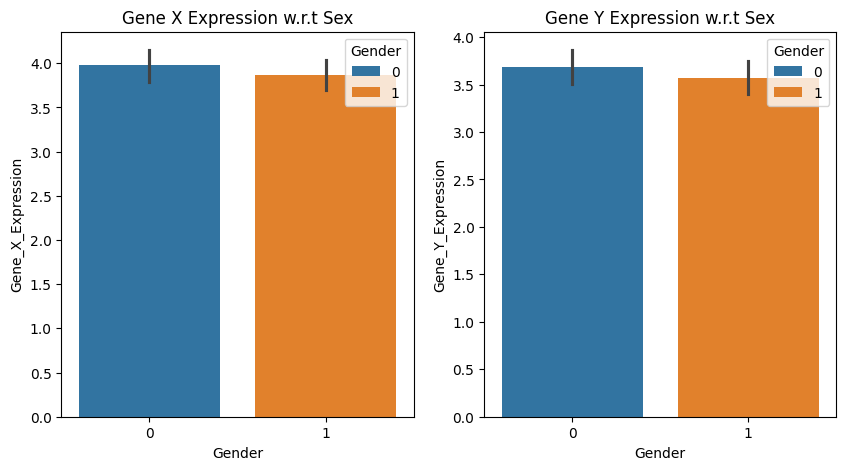

In [3]:

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gene X Expression w.r.t Sex")
sns.barplot(x = 'Gender' , y = 'Gene_X_Expression',data=df, hue="Gender" )
plt.subplot(1, 2, 2)
plt.title("Gene Y Expression w.r.t Sex")
sns.barplot(x = 'Gender' , y = 'Gene_Y_Expression',data=df, hue="Gender" )
plt.show()



In [5]:
colors = ["salmon", "lightblue", "lightgreen", "gold"]
for i, col in enumerate(["Age", "Gene_X_Expression", "Gene_Y_Expression"]):
  plot_hist(df, col, colors[i])

NameError: name 'plot_hist' is not defined

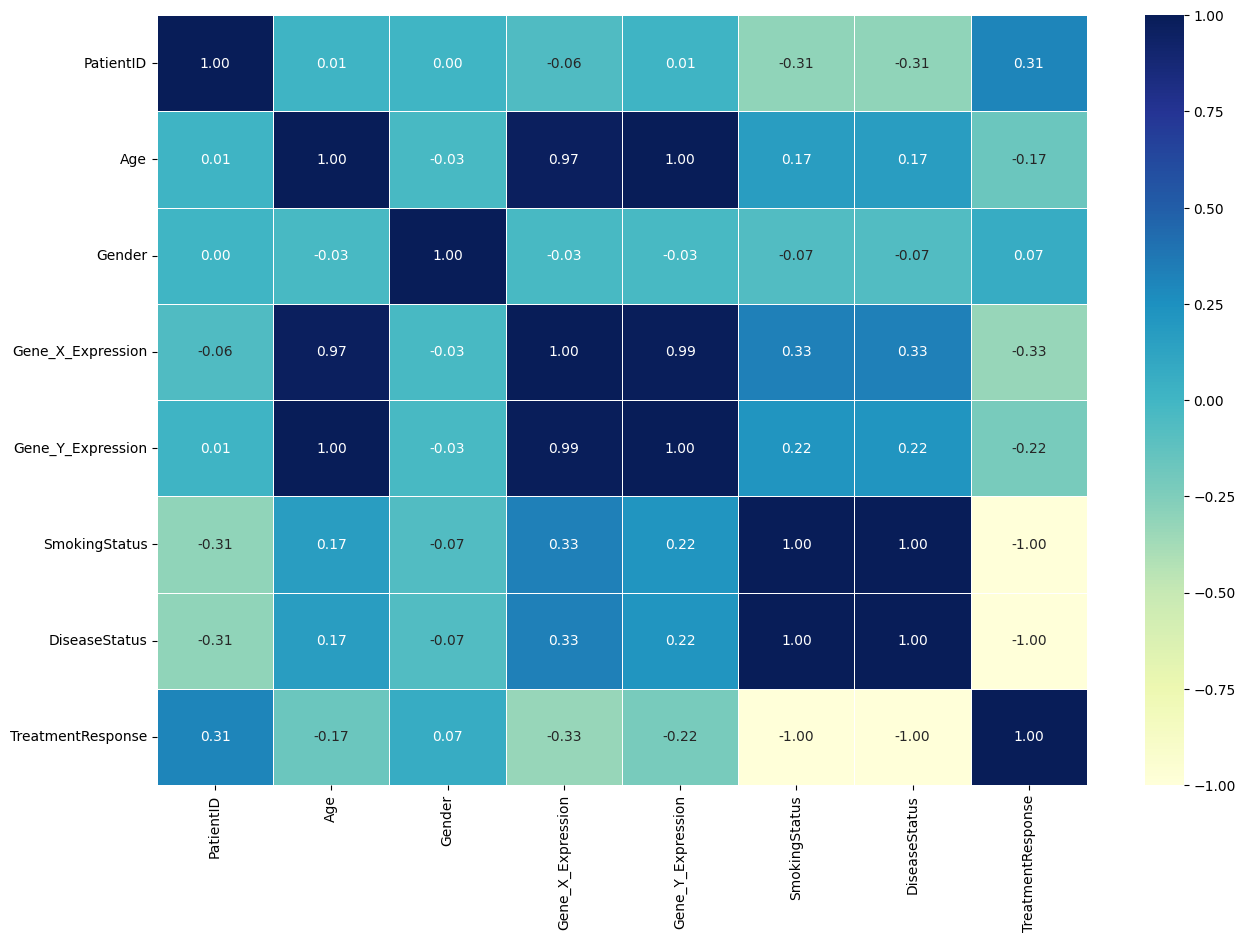

In [6]:
corr_matrix = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, linewidth=0.5, fmt=".2f",cmap="YlGnBu")
plt.show()

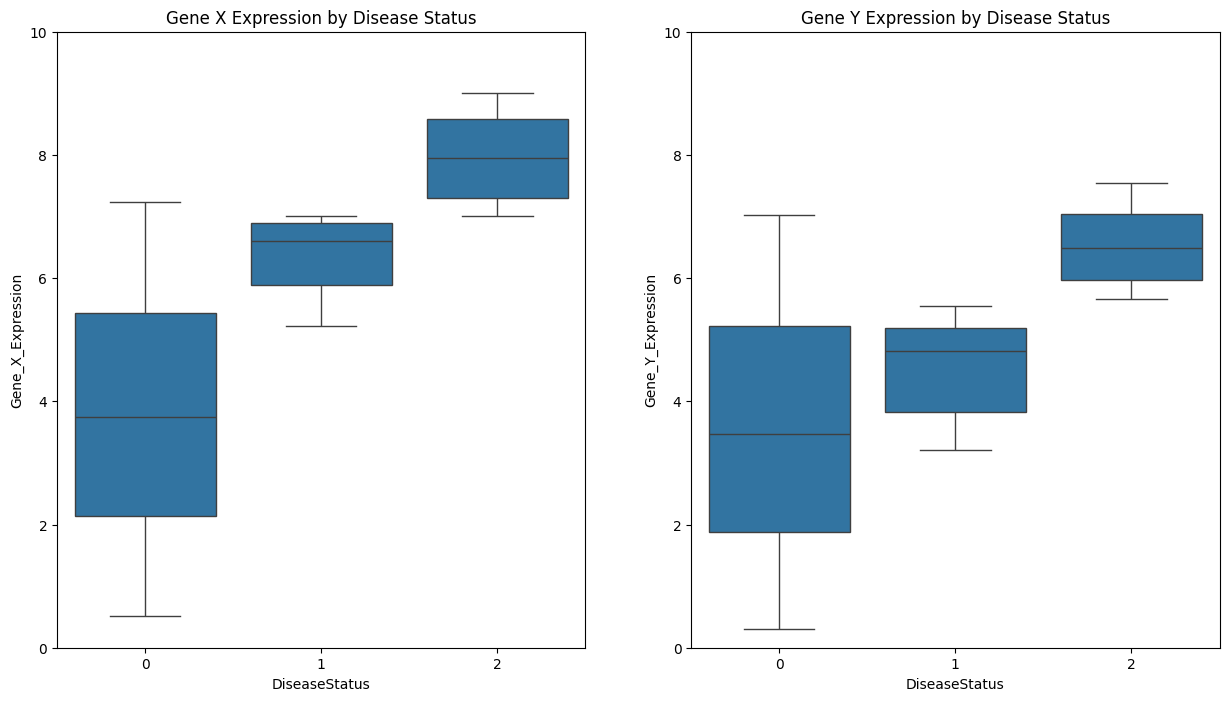

In [7]:
# Box plots: Gene expression by disease groups

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (15,8))


# Box plot: Gene X expression FOR EACH disease group
sns.boxplot(data=df, x="DiseaseStatus", y="Gene_X_Expression", ax = ax1)
ax1.set_title("Gene X Expression by Disease Status")


# Box plot for Gene Y
sns.boxplot(data=df, x="DiseaseStatus", y="Gene_Y_Expression", ax = ax2)
ax2.set_title("Gene Y Expression by Disease Status")

# we corrected ylim due to comparabilty
ax1.set_ylim(0, 10)
ax2.set_ylim(0, 10)

plt.show()


In [ ]:
target = "charges"
features = ["age", "sex", "bmi", "children", "smoker", "region"]
X = df[features].copy()
y = df[target].copy()